# Figure 4 — HSP90 chaperone buffering

Panels are built from `output/annotated_combined.tsv` (see `Annotations.ipynb`)
and written to `output/figures/fig4/`.

| Panel | Content |
|---|---|
| 4A | HSP90i abundance measurements per protein |
| 4B | Fractional change in standardised abundance, by variant type, with wild type |
| 4C | Buffering classes by domain context |
| 4D | Kinase-domain missense: score violins with class composition |
| S4A | The same for all missense |
| 4E | Buffering classes on the kinase fold (3E5A) |
| 4F | Buffering vs four predictors, pooled |
| S4C | The same per protein |
| 4G | Buffering classes by activity class |
| S4B | Per-protein univariate importance of each feature |

---
## The two scales, and which panel is on which

Every number here is on one of two scales. They answer different questions and
are never mixed within a panel.

**Dependence** is absolute. It asks *does this variant's abundance fall when
HSP90 is inhibited?* It is computed on `intercept_0_standard-adjusted score`,
which retains the global wild-type shift between conditions. Panel 4B.

**Buffering** is wild-type-relative. It asks *is this variant reduced relative
to its own wild type, and in which condition?* It is computed on
`average score`, which re-anchors wild type to 1.0 **within each condition**, so
the global shift cancels. Panels 4C–4G, S4A–S4C.

The distinction matters because HSP90 inhibition lowers most wild-type proteins
too. A variant can therefore be strongly *dependent* — its abundance drops a
lot — while not being *buffered* at all, because it drops no more than its own
wild type does. In the strong clients that is the common case, which is why 4B
overlays the wild-type value on every protein: a variant distribution sitting on
top of its own wild-type dash has no variant-specific effect however far from
zero it sits.

**Buffering classes** (locked; `docs/hsp90_metric_definitions.md`):

| Class | Control | HSP90i |
|---|---|---|
| **Buffered** | not low | **low** |
| **Poorly buffered** | low | low |
| **WT-like or high** | not low | not low |
| *(dropped)* | low | not low |

"Low" is `score < synonymous-WT 2.5th percentile`, computed per **(library,
assay, treatment)** — matching the granularity at which `classification_2.5pct`
is computed in the scoring pipeline. The fourth cell is dropped: it has no
mechanistic reading in a chaperone frame and is <2% of paired variants.

In [1]:
%load_ext autoreload
%autoreload 2
# Edits to utils.py take effect without restarting the kernel. Note that
# autoreload re-executes changed module bodies, so any module-level constant
# reassigned from the notebook (e.g. utils.BUFFERING_COLORS = ...) is reset on
# reload — pass such overrides as function arguments instead.

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.insert(0, "scripts")          # for the substitution-chemistry helper
import utils
from utils import (ANNOTATED_COMBINED, OUTPUT, SCORE_WT_REL, SCORE_ABS)

utils.apply_style()
FIG = OUTPUT / "figures" / "fig4"
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 170)

COLS = ["protein", "library", "assay", "assay_treatment", "variant",
        "Mutation Type", "Wild Type Residue", "Mutation", "Position",
        SCORE_WT_REL, SCORE_ABS, "classification_2.5pct", "DN_EV",
        "domain", "relative_sasa", "ddG_SPURS", "jsd_conservation",
        "phylop_vert", "kinase_motif", "active_site",
        "interface_pdb_curated", "at_hsp90_unfolded", "at_hsp90_folded",
        "at_cdc37", "chaperone_contact_resolved",
        "client_status_literature"]

### Analysis helpers

Defined here, not in `utils.py`, which is rendering-only. The pairing and the
class assignment are the two decisions this whole figure rests on, so they
belong where they can be read alongside the panels.

In [3]:
def load_scored():
    return pd.read_csv(ANNOTATED_COMBINED, sep="\t", low_memory=False,
                       usecols=list(dict.fromkeys(COLS)))


def pair_abundance(ann, score_col, proteins=tuple(utils.HSP90I_PROTEINS)):
    '''Pair each variant's control and HSP90i abundance **within its library**.

    Per library, not per protein: a split protein's nterm and cterm halves are
    never mixed. That matters for ARAF, whose cterm control is DMSO while its
    nterm control is No_treatment (gotcha G7).
    '''
    ab = ann[(ann.assay == "abundance") & ann.protein.isin(set(proteins))].copy()
    ctrl = ab[ab.assay_treatment.isin(utils.BASELINE_TREATMENTS)].copy()
    hsp = ab[ab.assay_treatment == "HSP90i"]
    ctrl["_pref"] = (ctrl.assay_treatment == "DMSO").astype(int)
    ctrl = (ctrl.sort_values("_pref", ascending=False)
            .drop_duplicates(["protein", "library", "variant"]).drop(columns="_pref"))
    key = ["protein", "library", "variant"]
    out = ctrl.merge(hsp[key + [score_col]].rename(columns={score_col: "hsp90i_score"}),
                     on=key, how="inner")
    out = out.rename(columns={score_col: "ctrl_score",
                              "assay_treatment": "ctrl_treatment"})
    return out.dropna(subset=["ctrl_score", "hsp90i_score"]).reset_index(drop=True)


def syn_wt_low_threshold(ann, score_col):
    '''Synonymous-WT 2.5th percentile per (library, assay, treatment).

    Same grouping the scoring pipeline uses for classification_2.5pct, which is
    what keeps anything derived from it consistent with that column.
    '''
    syn = ann[(ann["Mutation Type"] == "synonymous wild type")].dropna(subset=[score_col])
    return (syn.groupby(["library", "assay", "assay_treatment"])[score_col]
            .quantile(0.025).rename("threshold").reset_index())


def assign_buffering(paired, ann, score_col):
    '''The three buffering classes. Wild-type-relative.

        Buffered         not low in control, low in HSP90i
        Poorly buffered  low in both
        WT-like or high  not low in either
        (dropped)        low in control, not low in HSP90i

    'Low' is score < synonymous-WT 2.5th percentile computed separately in each
    condition, so every variant is judged against its own condition's wild
    type. That per-condition re-anchoring is what makes this the buffering
    scale: a protein whose wild type collapses under HSP90i does not thereby
    become buffered. The fourth cell is dropped — no mechanistic reading in a
    chaperone frame, and <2% of paired variants.
    '''
    thr = syn_wt_low_threshold(ann, score_col)
    ab = thr[thr.assay == "abundance"]
    ctrl_thr = (ab[ab.assay_treatment.isin(utils.BASELINE_TREATMENTS)]
                .set_index(["library", "assay_treatment"])["threshold"])
    hsp_thr = ab[ab.assay_treatment == "HSP90i"].set_index("library")["threshold"]

    out = paired.copy()
    out["ctrl_threshold"] = pd.MultiIndex.from_arrays(
        [out.library, out.ctrl_treatment]).map(ctrl_thr)
    out["hsp90i_threshold"] = out.library.map(hsp_thr)
    ctrl_low = out.ctrl_score < out.ctrl_threshold
    hsp_low = out.hsp90i_score < out.hsp90i_threshold
    cls = pd.Series(np.nan, index=out.index, dtype=object)
    cls[(~ctrl_low) & hsp_low] = "Buffered"
    cls[ctrl_low & hsp_low] = "Poorly buffered"
    cls[(~ctrl_low) & (~hsp_low)] = "WT-like or high"
    out["buffering_class"] = cls
    return out


def activity_group(df):
    g = df["classification_2.5pct"].astype(object).copy()
    g[df["DN_EV"] == True] = "DN"   # noqa: E712
    return g


ann = load_scored()
print(f"loaded {len(ann):,} rows")
print("HSP90i-profiled proteins:",
      ", ".join(utils.protein_labels(utils.HSP90I_PROTEINS)))

loaded 531,797 rows
HSP90i-profiled proteins: ARAF, BRAF, CRAF, EGFR, KSR2, MEK1, MEK2, HGFR, RET, SOS2


## 4A — what was measured

Per-protein count of variants with an HSP90i abundance measurement, following
the project's TOTAL-COUNT rule: include every biologically meaningful variant
type — missense, synonymous wild type, deletion, nonsense and wild type — and
exclude only meaningless data. The exclusion is the BRAF spike-in standards,
which appear in every library; counting them per protein would inflate every
non-BRAF slice by the same handful of BRAF variants.

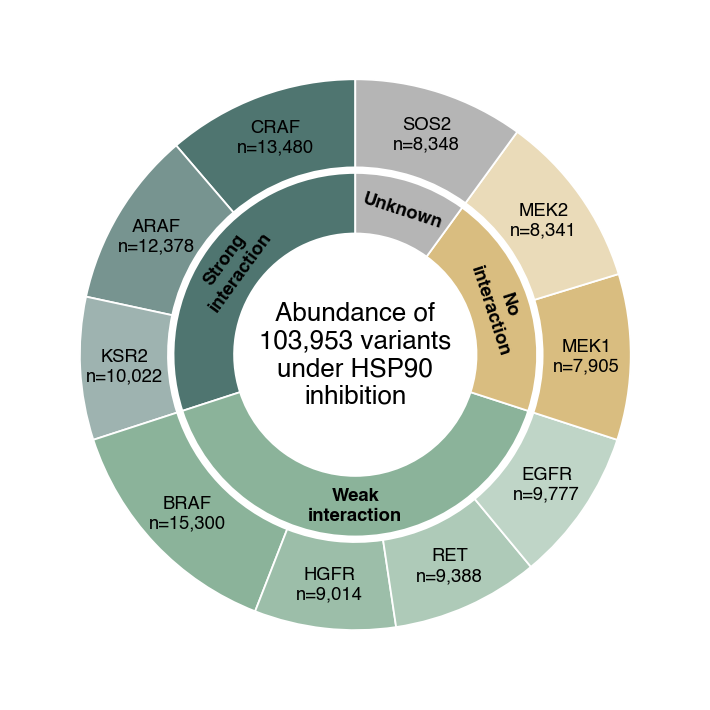

total = 103,953 variants across 10 proteins


,CRAF,ARAF,KSR2,BRAF,HGFR,RET,EGFR,MEK1,MEK2,SOS2
variants,13480,12378,10022,15300,9014,9388,9777,7905,8341,8348


In [4]:
COUNTED_TYPES = {"missense", "synonymous wild type", "deletion", "nonsense",
                 "wild type"}
hsp_ab = ann[(ann.assay == "abundance") & (ann.assay_treatment == "HSP90i")
             & ann["Mutation Type"].isin(COUNTED_TYPES)]
counts = hsp_ab.groupby("protein").size().to_dict()

# Taipale 2012 client status. The
# inner ring is one wedge per status, sized by how many PROTEINS hold it (not
# by variant count) — the ring answers "how much of the pathway is a client",
# and weighting by library size would let one deep library speak for a status.
HSP90_CLIENT_STATUS = {
    "craf": "strong", "araf": "strong", "ksr2": "strong",
    "braf": "weak", "met": "weak", "ret": "weak", "egfr": "weak",
    "mek1": "non", "mek2": "non",
    "sos2": "unknown",
}
STATUS_ORDER = ["strong", "weak", "non", "unknown"]
STATUS_LABELS = {"strong": "Strong\ninteraction", "weak": "Weak\ninteraction",
                 "non": "No\ninteraction", "unknown": "Unknown"}
# Reserved teal/sage/wheat/grey palette: deliberately clear of the dependence
# palette and of the canonical buffering red/orange/blue, so client status is
# never read as a buffering result.
STATUS_COLORS = {"strong": "#4F7570", "weak": "#8BB39A",
                 "non": "#D9BD80", "unknown": "#B5B5B5"}

grouped = {s: [p for p, st in HSP90_CLIENT_STATUS.items() if st == s]
           for s in STATUS_ORDER}

inner_sizes = [len(grouped[s]) for s in STATUS_ORDER]
inner_colors = [STATUS_COLORS[s] for s in STATUS_ORDER]
inner_labels = [STATUS_LABELS[s] for s in STATUS_ORDER]

# Outer ring: one slice per protein, nested inside its status wedge. A status
# holding k proteins spans k inner units, and its proteins split that span in
# proportion to their variant counts — so the two rings stay concentric while
# the outer ring still encodes how much was actually measured.
outer_sizes, outer_colors, outer_labels = [], [], []
for status in STATUS_ORDER:
    prots = grouped[status]
    if not prots:
        continue
    total = sum(counts[p] for p in prots) or 1
    base = np.array(mcolors.to_rgb(STATUS_COLORS[status]))
    for i, p in enumerate(prots):
        # Shade evenly toward white across the group so neighbouring slices in
        # a multi-protein status stay distinguishable; a lone protein keeps the
        # base colour.
        lighten = 0.0 if len(prots) == 1 else 0.45 * i / (len(prots) - 1)
        outer_sizes.append(len(prots) * counts[p] / total)
        outer_colors.append(tuple(base + (1.0 - base) * lighten))
        outer_labels.append(f"{utils.protein_label(p)}\nn={counts[p]:,}")

total_n = sum(counts[p] for p in HSP90_CLIENT_STATUS)
fig, _ = utils.plot_donut(
    outer_sizes, outer_colors, outer_labels,
    inner_sizes=inner_sizes, inner_colors=inner_colors,
    inner_labels=inner_labels,
    center_label=f"Abundance of\n{total_n:,} variants\nunder HSP90\ninhibition")
utils.save_figure(fig, FIG / "fig4a_hsp90i_measurement_wheel")
plt.show()
print(f"total = {total_n:,} variants across {len(HSP90_CLIENT_STATUS)} proteins")
display(pd.Series({utils.protein_label(p): counts[p]
                   for p in HSP90_CLIENT_STATUS}, name="variants").to_frame().T)


## 4B — dependence: fractional change in abundance

`(HSP90i − control) / control` on the standard-adjusted score, per variant.
This is the **absolute** scale, so it registers the global wild-type shift —
which is exactly why the wild-type value is drawn as a black dash on every
protein. Read the panel as: how far is each variant distribution displaced from
zero, *and* how much of that displacement does its own wild type already
account for?

Missense and nonsense are shown separately. Nonsense variants largely do not
fall, consistent with HSP90 acting on full-length kinases whose folding can
still be completed rather than on truncated products.

paired on the absolute scale: 110,360 variants


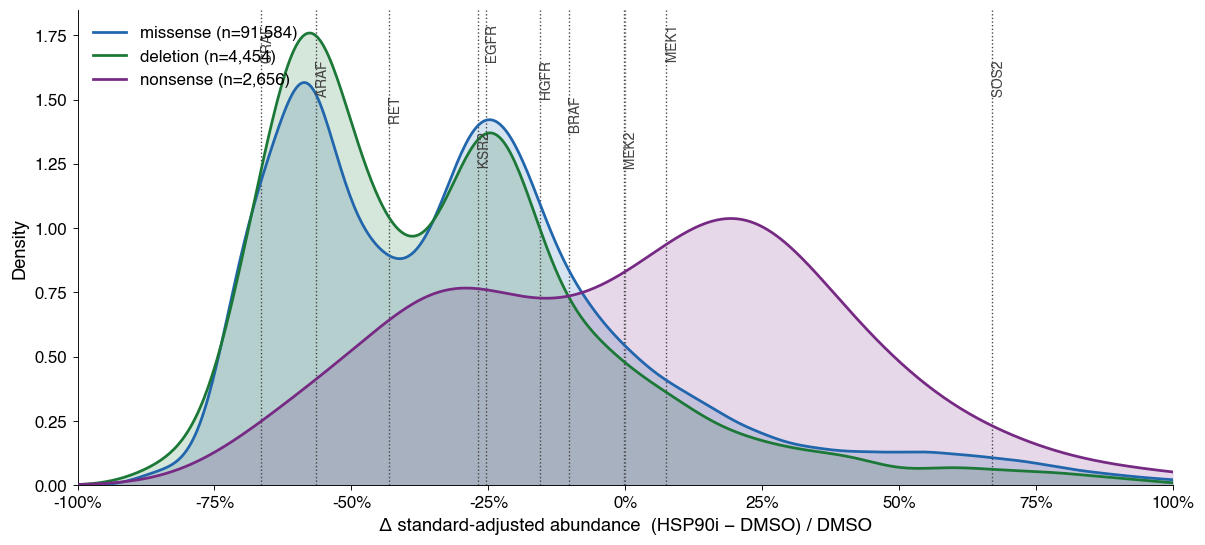

,n,median,WT,WT ratio
protein,,,,
craf,11810,-0.670,-0.665,0.335
araf,10818,-0.574,-0.565,0.435
ret,8552,-0.470,-0.432,0.568
ksr2,8709,-0.257,-0.270,0.730
egfr,8847,-0.294,-0.255,0.745
met,8205,-0.299,-0.155,0.845
braf,13050,-0.178,-0.102,0.898
mek2,7307,-0.140,-0.003,0.997
mek1,6880,0.093,0.074,1.074



WT ratio near 1.0 => wild type essentially unaffected, so any shift in the variant distribution is variant-specific. Those are the WT-controlled comparisons; the strong clients are not among them.


In [5]:
SCORE_ABS = "intercept_0_standard-adjusted score"
paired_abs = pair_abundance(ann, SCORE_ABS)
# Fractional change on the ABSOLUTE scale: the standard-adjusted score retains
# the global wild-type shift between conditions, which is what puts this panel
# on the dependence scale rather than the buffering scale. Negative = abundance
# falls under HSP90 inhibition, as a fraction of the variant's own control
# abundance; positive = a paradoxical increase.
paired_abs["frac_change"] = ((paired_abs.hsp90i_score - paired_abs.ctrl_score)
                             / paired_abs.ctrl_score.replace(0, np.nan))
print(f"paired on the absolute scale: {len(paired_abs):,} variants")

# One distribution per variant type, pooled over proteins. Deletions are shown
# alongside missense because figure 3 groups them, and nonsense is the built-in
# floor: it removes the protein, so wherever nonsense sits is roughly where
# "no protein left" reads on this axis.
TYPES = ["missense", "deletion", "nonsense"]
pa = paired_abs[paired_abs["Mutation Type"].isin(TYPES)]

# The dotted lines are the wild types. They carry the panel: a variant
# distribution sitting far below zero means nothing on its own if that
# protein's own wild type has dropped just as far — which is exactly the case
# in the strong clients. SOS2 is included and sits on the far side of zero,
# since WT SOS2 *rises* under HSP90 inhibition.
wt_frac = (paired_abs[paired_abs["Mutation Type"] == "wild type"]
           .groupby("protein").frac_change.mean())
wt_lines = {utils.protein_label(p): float(v) for p, v in wt_frac.items()
            if np.isfinite(v)}

fig, _ = utils.plot_density_panel(
    {t_: pa.loc[pa["Mutation Type"] == t_, "frac_change"].to_numpy()
     for t_ in TYPES},
    colors=utils.VARIANT_TYPE_COLORS,
    marker_lines=wt_lines, ref_line=0.0, x_percent=True,
    # Fixed to -100%..+100%: -100% is total loss of the protein, the floor the
    # measure can reach, and +100% is a doubling. A symmetric axis about zero
    # also makes the paradoxical-increase side directly comparable to the loss
    # side by eye, which a data-driven range would not.
    xlim=(-1.0, 1.0),
    xlabel="Δ standard-adjusted abundance  (HSP90i − DMSO) / DMSO",
    ylabel="Density")
utils.save_figure(fig, FIG / "fig4b_fractional_dependence")
plt.show()

summ = (pa[pa["Mutation Type"] == "missense"].groupby("protein").frac_change
        .agg(n="size", median="median").round(3))
summ["WT"] = wt_frac.round(3)
summ["WT ratio"] = (1 + summ["WT"]).round(3)
display(summ.reindex([p for p in utils.HSP90_ORDER if p in summ.index]))
print("\nWT ratio near 1.0 => wild type essentially unaffected, so any shift in "
      "the variant distribution is variant-specific. Those are the "
      "WT-controlled comparisons; the strong clients are not among them.")


## 4C — buffering is concentrated in kinase domains

Buffering classes by domain context. The kinase-domain enrichment is the
domain preference expected from CDC37's role as a kinase-family-specific
recognition factor. Non-kinase domains (the RAF RBD and CRD) behave like
unstructured regions, so this is genuinely kinase-fold-specific rather than
merely "inside a domain".

paired missense+deletion with a buffering class: 93,003 of 96,038 (3.2% dropped as control-low / HSP90i-not-low)
   of which missense only (the factor-panel cohort): 91,584


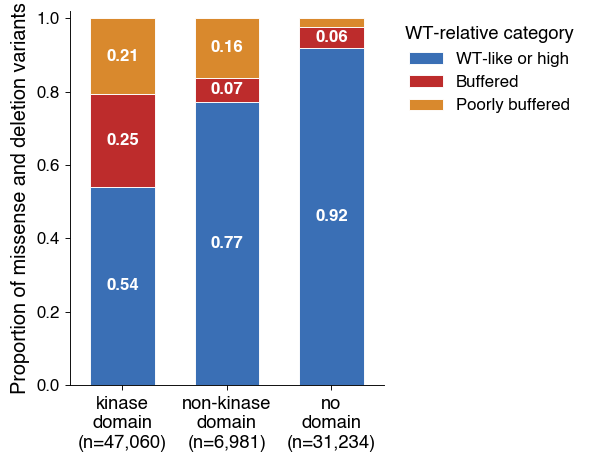

buffering_class,WT-like or high,Buffered,Poorly buffered
domain_grp,,,
kinase\ndomain,54.0,25.2,20.8
non-kinase\ndomain,77.2,6.7,16.2
no\ndomain,91.8,5.8,2.4


In [6]:
paired_all = pair_abundance(ann, SCORE_WT_REL)
paired_all = assign_buffering(paired_all, ann, SCORE_WT_REL)

# TWO cohorts, because the panels split on what their predictors support.
#
# `paired_md` is missense AND deletion, grouped as in figure 3, and drives the
# composition panels (4C, 4G) plus the score violins.
#
# `paired` is missense only and drives the factor panels (4F, S4C, S4B). Those
# are restricted for a hard reason, not a stylistic one: SPURS ddG is defined
# for 0.0% of deletions against 100% of missense, so a deletion cannot be placed
# on the ΔΔG axis at all. Several S4B features are likewise substitution-specific
# (Grantham, BLOSUM62, to/from proline, Δ hydrophobicity ...).
paired_md = paired_all[paired_all["Mutation Type"].isin(["missense", "deletion"])]
paired = paired_all[paired_all["Mutation Type"] == "missense"]
print(f"paired missense+deletion with a buffering class: "
      f"{int(paired_md.buffering_class.notna().sum()):,} of {len(paired_md):,} "
      f"({paired_md.buffering_class.isna().mean():.1%} dropped as control-low / "
      "HSP90i-not-low)")
print(f"   of which missense only (the factor-panel cohort): {len(paired):,}")

# The domain panel uses the 9 profiled proteins, excluding SOS2: SOS2
# sits alone in the Unknown client status and has no kinase / non-kinase / no
# domain split to contribute, so including it would add a column of one class.
DOMAIN_PANEL_PROTEINS = ["araf", "craf", "ksr2", "ret", "egfr", "braf", "met",
                         "mek1", "mek2"]

# Three domain contexts. The annotated `domain` is fine-grained, so anything
# that is neither the kinase domain nor unannotated is "non-kinase domain" —
# the RAF RBD/CRD, the SH2s, the MEK docking regions.
DOM_ORDER = ["kinase\ndomain", "non-kinase\ndomain", "no\ndomain"]


def domain_group(d) -> str:
    if not isinstance(d, str) or d == "none":
        return "no\ndomain"
    return "kinase\ndomain" if d == "kinase" else "non-kinase\ndomain"


dom = paired_md[paired_md.protein.isin(DOMAIN_PANEL_PROTEINS)].dropna(
    subset=["buffering_class"]).copy()
dom["domain_grp"] = dom.domain.map(domain_group)
ctx = (dom.groupby(["domain_grp", "buffering_class"]).size()
       .unstack(fill_value=0)
       .reindex(index=DOM_ORDER, columns=utils.BUFFERING_STACK_ORDER,
                fill_value=0))
n_ctx = ctx.sum(axis=1)

fig, _ = utils.plot_stacked_vbar(
    ctx.div(n_ctx, axis=0), colors=utils.BUFFERING_COLORS, n_by_row=n_ctx,
    ylabel="Proportion of missense and deletion variants")
utils.save_figure(fig, FIG / "fig4c_buffering_by_domain_context")
plt.show()
display((ctx.div(n_ctx, axis=0) * 100).round(1))


## 4D and S4A — per-protein distributions with class composition

The violin is the abundance-score distribution under HSP90 inhibition; the
strip directly above shows what fraction of that protein's variants fall in each
buffering class. Sharing the x-axis lets a compressed distribution be connected
to its class composition without cross-referencing panels.

4D is kinase-domain missense and deletion — the cohort every downstream HSP90
analysis uses, grouped as in figure 3. S4A is all missense and deletion, which brings in the RAF non-kinase domains and shows the
same protein ordering with a diluted signal.

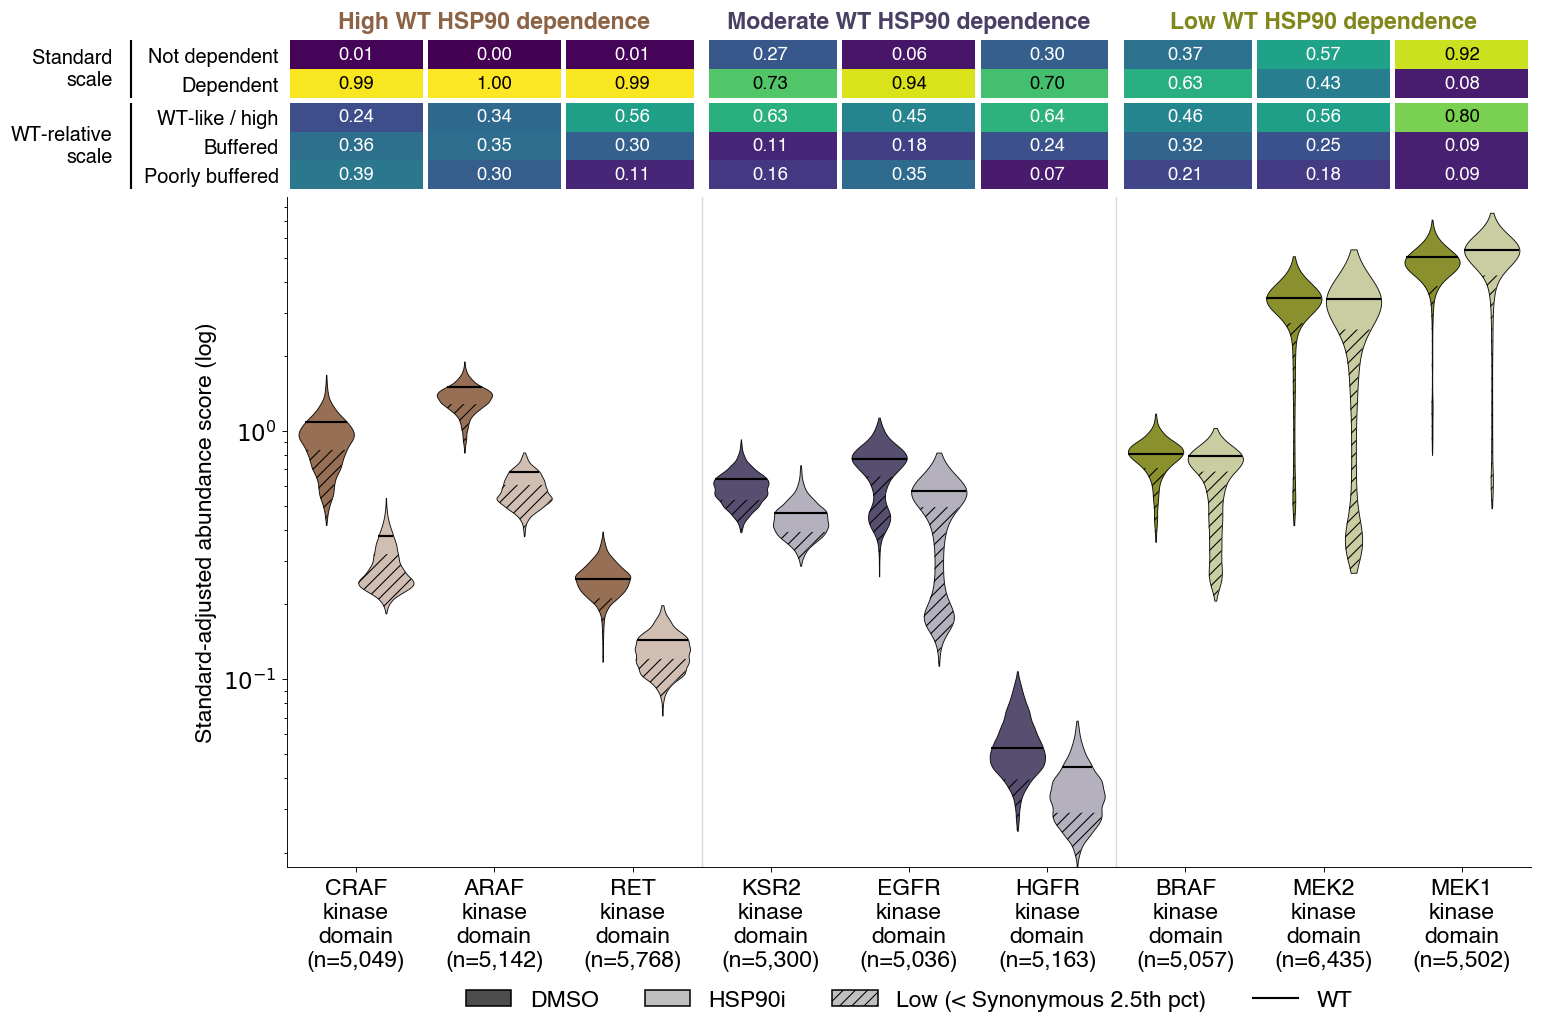

,not_dependent,dependent,wt_like,buffered,poorly_buffered
craf,0.010,0.990,0.235,0.363,0.395
araf,0.001,0.999,0.337,0.353,0.296
ret,0.008,0.992,0.561,0.305,0.109
ksr2,0.271,0.729,0.634,0.108,0.163
egfr,0.056,0.944,0.453,0.185,0.346
met,0.300,0.700,0.644,0.244,0.071
braf,0.375,0.625,0.457,0.321,0.208
mek2,0.575,0.425,0.559,0.247,0.175
mek1,0.919,0.081,0.799,0.089,0.087


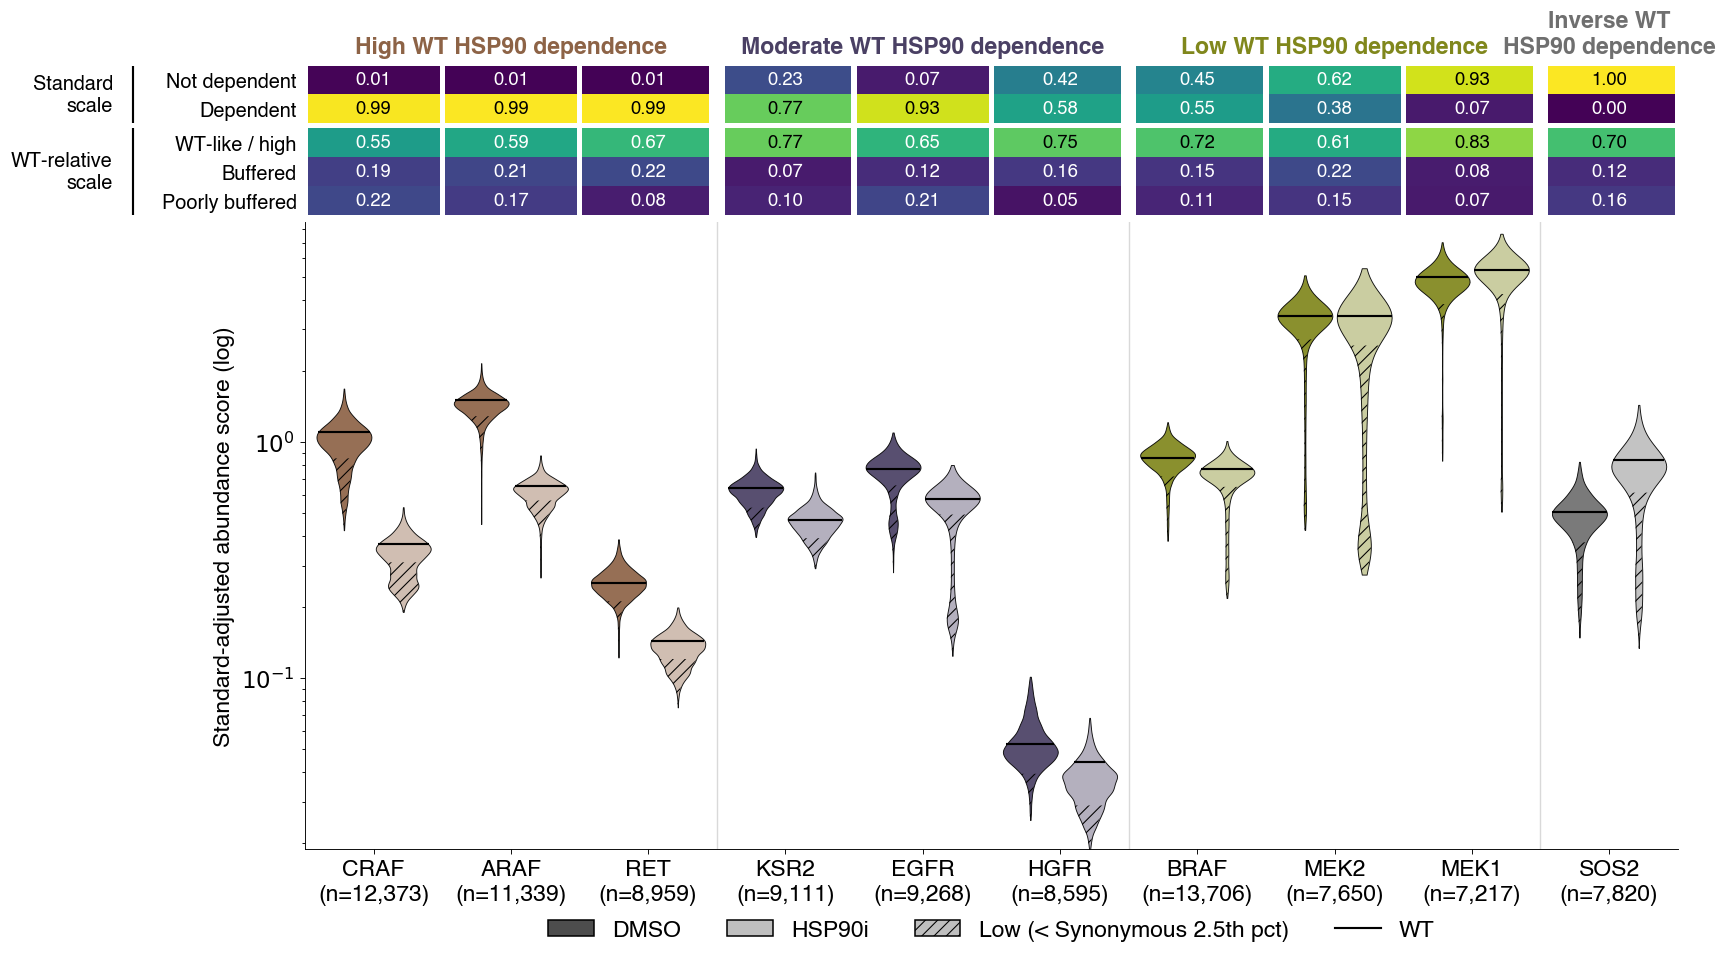

,not_dependent,dependent,wt_like,buffered,poorly_buffered
craf,0.010,0.990,0.549,0.185,0.216
araf,0.007,0.993,0.594,0.208,0.172
ret,0.007,0.993,0.665,0.220,0.081
ksr2,0.234,0.766,0.767,0.073,0.097
egfr,0.072,0.928,0.651,0.121,0.206
met,0.422,0.578,0.752,0.163,0.049
braf,0.452,0.548,0.719,0.152,0.105
mek2,0.615,0.385,0.609,0.222,0.149
mek1,0.932,0.068,0.829,0.076,0.070
sos2,0.996,0.004,0.703,0.122,0.163



kinase-domain paired, WT-relative scale: missense 46,253 (44,905 with a buffering class); missense+deletion 48,452 (47,060 with a class)


In [7]:
# 4D / S4A are on the ABSOLUTE scale, so they use the standard-adjusted score
# (which keeps the global wild-type shift between conditions) rather than the
# WT-relative score used by 4C and 4E-4G.
SCORE_ABS = "intercept_0_standard-adjusted score"
NOTLOW = ("wt-like", "high")

# Proteins grouped by how much their WILD TYPE depends on HSP90 — the grouping
# is the point of the panel: it lets a variant's response be read against the
# backdrop of its protein's own wild-type response. SOS2 is its own group
# because the sign is reversed, not merely small: WT SOS2 and most of its
# missense variants *rise* under HSP90 inhibition. It is given a neutral grey
# rather than a hue on the high->low ramp so it reads as off the scale.
# The tiers, spelling out utils.HSP90_ORDER's grouping. Asserted against it so
# the constant and the tier membership cannot drift apart.
DEP_GROUPS_KD = [                          # 4D: kinase domain, so no SOS2
    ("High WT HSP90 dependence",     ["craf", "araf", "ret"]),
    ("Moderate WT HSP90 dependence", ["ksr2", "egfr", "met"]),
    ("Low WT HSP90 dependence",      ["braf", "mek2", "mek1"]),
]
assert [p for _, ps in DEP_GROUPS_KD for p in ps] == utils.HSP90_ORDER
DEP_GROUPS_ALL = DEP_GROUPS_KD + [("Inverse WT\nHSP90 dependence", ["sos2"])]
# Dark -> warm ramp, deliberately clear of the buffering red/orange/blue so a
# tier colour is never read as a buffering class.
GROUP_FILL = {
    "High WT HSP90 dependence":     "#8D6346",
    "Moderate WT HSP90 dependence": "#4A4064",
    "Low WT HSP90 dependence":      "#80871C",
    "Inverse WT\nHSP90 dependence": "#6F6F6F",
}
HEATMAP_KEYS = ("not_dependent", "dependent",
                "wt_like", "buffered", "poorly_buffered")
HEATMAP_LABELS = {"not_dependent": "Not dependent", "dependent": "Dependent",
                  "wt_like": "WT-like / high", "buffered": "Buffered",
                  "poorly_buffered": "Poorly buffered"}

abs_mf = ann[(ann.assay == "abundance")
             & ann.assay_treatment.isin(["DMSO", "No_treatment", "HSP90i"])].copy()
abs_mf["tx"] = np.where(abs_mf.assay_treatment == "HSP90i", "hsp90i", "ctrl")


def violin_inputs(proteins, *, kinase_only: bool):
    """arrays / WT / low-threshold / heatmap fractions, per (protein, treatment).

    Split-library handling is the one place the two panels differ structurally.
    ARAF, BRAF and CRAF are each tiled by an N- and a C-terminal library, and
    the kinase domain lives only in the C-terminal one. For 4D that means a
    single library carries all the data, and the WT marker and the synonymous
    threshold are taken from that library so they sit on the same standard
    curve as the scores. For S4A both libraries contribute, so the missense
    pool is concatenated, the WT marker is the MEAN of the per-library WT rows
    and the synonymous threshold is computed on the pooled synonymous scores.
    Pooling is legitimate here precisely because the score is standard-adjusted:
    each library is projected onto a shared internal-standard curve, so the two
    halves of a split RAF are on a common scale.

    `classification_2.5pct` is a per-library label, so buffering is always
    paired WITHIN a library and the paired tables are concatenated afterwards.
    """
    # Missense AND single-residue deletions, matching how figure 3 groups them:
    # both are protein-altering changes that leave a full-length-ish product
    # able to poison, whereas nonsense removes the protein outright. Deletions
    # are a small part of the kinase-domain pool, so they shift the
    # violins little but make the cohort consistent across figures.
    miss = abs_mf[abs_mf["Mutation Type"].isin(["missense", "deletion"])]
    if kinase_only:
        miss = miss[miss.domain == "kinase"]
    syn = abs_mf[abs_mf["Mutation Type"] == "synonymous wild type"]
    wt_rows = abs_mf[abs_mf["Mutation Type"] == "wild type"]

    arrays, wt, thresholds, heat = {}, {}, {}, {}
    for p in proteins:
        mp = miss[miss.protein == p]
        # For 4D the library is the one the kinase-domain missense sits in.
        libs = ([mp.library.mode().iloc[0]] if kinase_only and len(mp)
                else sorted(abs_mf.loc[abs_mf.protein == p, "library"].unique()))
        for tx in ("ctrl", "hsp90i"):
            s = mp[(mp.tx == tx) & mp.library.isin(libs)][SCORE_ABS].dropna()
            # Clip at a display floor: log10(0) is undefined and a handful of
            # pathological negatives would otherwise set the axis range.
            arrays[(p, tx)] = np.clip(s.to_numpy(dtype=float), 0.01, None)
            w = wt_rows[(wt_rows.protein == p) & (wt_rows.tx == tx)
                        & wt_rows.library.isin(libs)][SCORE_ABS]
            wt[(p, tx)] = float(w.mean()) if len(w) else np.nan
            sy = syn[(syn.protein == p) & (syn.tx == tx)
                     & syn.library.isin(libs)][SCORE_ABS].dropna()
            thresholds[(p, tx)] = (float(np.percentile(sy.to_numpy(), 2.5))
                                   if len(sy) else np.nan)

        # Buffering fractions: pair within library, then pool.
        parts = []
        for lib in libs:
            sl = mp[mp.library == lib]
            c = (sl[sl.tx == "ctrl"][["variant", SCORE_ABS, "classification_2.5pct"]]
                 .rename(columns={SCORE_ABS: "s_c", "classification_2.5pct": "cl_c"}))
            h = (sl[sl.tx == "hsp90i"][["variant", SCORE_ABS, "classification_2.5pct"]]
                 .rename(columns={SCORE_ABS: "s_h", "classification_2.5pct": "cl_h"}))
            m = c.merge(h, on="variant")
            if len(m):
                parts.append(m)
        if not parts:
            heat[p] = {k: np.nan for k in HEATMAP_KEYS} | {"_n": 0}
            continue
        m = pd.concat(parts, ignore_index=True)
        n = len(m)

        # "Dependent" is an ABSOLUTE-scale call: the variant's score must fall,
        # between control and HSP90i, by at least the gap between wild type and
        # the synonymous 2.5th percentile in the control condition. Using that
        # gap as the yardstick makes the threshold the assay's own noise floor
        # rather than an arbitrary fold-change.
        wt_dmso = wt[(p, "ctrl")]
        syn_2p5 = thresholds[(p, "ctrl")]
        gap = (max(0.0, wt_dmso - syn_2p5)
               if np.isfinite(wt_dmso) and np.isfinite(syn_2p5) else 0.0)
        dep = float(((m.s_c - m.s_h) >= gap).sum() / n)
        c_nl, h_nl = m.cl_c.isin(NOTLOW), m.cl_h.isin(NOTLOW)
        c_lo, h_lo = m.cl_c == "low", m.cl_h == "low"
        heat[p] = {
            "not_dependent": 1.0 - dep, "dependent": dep,
            "wt_like": float((c_nl & h_nl).sum() / n),
            "buffered": float((c_nl & h_lo).sum() / n),
            "poorly_buffered": float((c_lo & h_lo).sum() / n),
            "_n": n,
        }
    return arrays, wt, thresholds, heat


# Violin support is trimmed to each series' 0.25th-99.75th percentile.
# matplotlib evaluates the KDE over the full data range, so a handful of extreme
# variants drags a thin sliver of density across the whole panel. 0.25% is where
# the drawn span stops shrinking appreciably as the trim widens; past it,
# trimming mostly eats real distribution.
#
# The y-axis stays on `ylim_pct` of the pooled data, so the two act together: the
# trim removes isolated far outliers, the axis crops what remains beyond the bulk.
#
# Display only -- every statistic (the heatmap fractions, the WT lines) is
# computed on the full data. It does mean the hatched "low" area marks where the
# threshold cuts rather than being a faithful area, which is why the exact
# fractions live in the heatmap.
TRIM = (0.25, 99.75)

# 4D — kinase-domain missense and deletion: the cohort used downstream.
a, w, th, hm = violin_inputs([p for _, ps in DEP_GROUPS_KD for p in ps],
                             kinase_only=True)
fig, _, _ = utils.plot_paired_score_violins(
    a, w, th, hm, groups=DEP_GROUPS_KD, group_fill=GROUP_FILL,
    heatmap_rows=HEATMAP_KEYS, heatmap_labels=HEATMAP_LABELS,
    figsize=(14.5, 9.4), height_ratios=(1.0, 4.5), trim_pct=TRIM,
    xtick_fmt="{label}\nkinase\ndomain\n(n={n:,})", legend_y=-0.245)
utils.save_figure(fig, FIG / "fig4d_kinase_domain_violins")
plt.show()
display(pd.DataFrame(hm).T[list(HEATMAP_KEYS)].round(3))

# S4A — all missense and deletion, bringing in the RAF non-kinase domains and
# SOS2, whose response is inverted.
a2, w2, th2, hm2 = violin_inputs([p for _, ps in DEP_GROUPS_ALL for p in ps],
                                 kinase_only=False)
fig, _, _ = utils.plot_paired_score_violins(
    a2, w2, th2, hm2, groups=DEP_GROUPS_ALL, group_fill=GROUP_FILL,
    heatmap_rows=HEATMAP_KEYS, heatmap_labels=HEATMAP_LABELS,
    figsize=(16.0, 8.9), height_ratios=(1.0, 4.2), trim_pct=TRIM)
utils.save_figure(fig, FIG / "figs4a_all_missense_violins")
plt.show()
display(pd.DataFrame(hm2).T[list(HEATMAP_KEYS)].round(3))

# The kinase-domain cohort on the WT-RELATIVE scale, carrying the buffering
# class. 4E-4G and S4C all work from this: they ask which variants are buffered,
# which is a WT-relative question, whereas the violins above are on the absolute
# standard-adjusted scale.
# `kd` is missense only — it feeds 4E/4F/S4C, whose predictors need ΔΔG.
kd = paired[paired.domain == "kinase"]
# `kd_md` adds deletions and feeds the activity-class composition panel (4G).
kd_md = paired_md[paired_md.domain == "kinase"]
print(f"\nkinase-domain paired, WT-relative scale: missense {len(kd):,} "
      f"({int(kd.buffering_class.notna().sum()):,} with a buffering class); "
      f"missense+deletion {len(kd_md):,} "
      f"({int(kd_md.buffering_class.notna().sum()):,} with a class)")


## 4E — buffering on the kinase fold

Per-position buffering fractions projected onto the kinase fold. The render
itself is PyMOL, produced by
`scripts/paint_consensus_buffering_structures.py`, which averages each
alignment column's class fractions across the nine profiled kinases and paints
them onto **3E5A** (Aurora-A) in the canonical Modi–Dunbrack pose.

This cell writes the per-position table the render consumes, so the structure
and every other panel in this figure derive from one classification.

In [8]:
per_pos = (kd.dropna(subset=["buffering_class"])
           .groupby(["protein", "Position", "buffering_class"]).size()
           .unstack(fill_value=0))
per_pos["n"] = per_pos.sum(axis=1)
for cls in utils.BUFFERING_ORDER:
    if cls not in per_pos:
        per_pos[cls] = 0
    per_pos[f"frac_{cls.replace(' ', '_').replace('-', '_').lower()}"] = (
        per_pos[cls] / per_pos["n"])
out = FIG / "fig4e_per_position_buffering.tsv"
per_pos.reset_index().to_csv(out, sep="\t", index=False)
print(f"wrote {out.relative_to(utils.PROJECT_ROOT)}  ({len(per_pos):,} positions across "
      f"{per_pos.reset_index().protein.nunique()} kinases)")
display(per_pos.reset_index().groupby("protein")
        [[f"frac_{c.replace(' ', '_').replace('-', '_').lower()}"
          for c in utils.BUFFERING_ORDER]].mean().round(3))
# ---- 3E5A renders, coloured by this notebook's buffering classes ---------
# Aurora-A (3E5A) as the reference kinase fold. Each class gets its own ramp
# from white to that class's locked colour, on a fixed 0-1 scale so the three
# panels are directly comparable; residues with no data are mid-grey, which is
# distinguishable from the white end of the ramp.
# ---- canonical kinase-domain pose, hard-coded ---------------------------
# The Modi & Dunbrack 2019 Fig 1 view
# and saved to output/hsp90/.../kinase_fold_reference_view.txt. Pinned here as
# a literal so this notebook does not depend on that file surviving.
#
# Recipe: load 1GAG (insulin receptor kinase) as the anchor, trim to the
# kinase domain (chain A, 995-1283, N-terminal tail removed so it does not
# dominate the view), orient, then apply the four rotations to the ANCHOR'S
# ATOMS. Each subject is then cealign'ed + super'ed onto the rotated anchor,
# which physically moves it into the same frame. The rotations must precede
# the alignment: cmd.rotate(axis, angle, selection) moves only that
# selection, so rotating afterwards would leave every subject behind.
KINASE_FOLD_VIEW = (
    0.4060613811016083, -0.6507185101509094, 0.6416226029396057,
    0.3824107050895691, -0.5166869163513184, -0.7660265564918518,
    0.8299856781959534, 0.5564171671867371, 0.03903511166572571,
    0.0, 0.0, -170.91629028320312,
    -22.87476348876953, 38.59135818481445, 11.818153381347656,
    134.751708984375, 207.08087158203125, -20.0,
)
KINASE_POSE = dict(
    align_to=str(utils.PROJECT_ROOT / "data" / "structures" / "1GAG.pdb"),
    align_chain="A", align_resi=(995, 1283),
    align_rotations=[("z", 90), ("x", 180), ("y", 180), ("y", -35)],
    view=KINASE_FOLD_VIEW,
)

RENDER_STRUCTURES = True   # ~1 min per panel; False writes the .pml only

consensus = (per_pos.reset_index()
             .groupby("Position")[[f"frac_{c.replace(' ', '_').replace('-', '_').lower()}"
                                   for c in utils.BUFFERING_ORDER]].mean())
for cls in utils.BUFFERING_ORDER:
    col = f"frac_{cls.replace(' ', '_').replace('-', '_').lower()}"
    stem = FIG / f"fig4e_structure_3e5a_{col}"
    utils.plot_structure(
        stem, structure="fetch:3E5A", query_chains=("A",), **KINASE_POSE,
        residue_values=consensus[col].to_dict(),
        cmap=utils.BUFFERING_CMAPS[cls], vmin=0.0, vmax=1.0,
        nodata_color="gray35", run=RENDER_STRUCTURES)
    print(f"  {cls:16s} -> {stem.name}.png "
          f"({consensus[col].notna().sum()} positions)")

wrote output/figures/fig4/fig4e_per_position_buffering.tsv  (2,503 positions across 9 kinases)


buffering_class,frac_buffered,frac_poorly_buffered,frac_wt_like_or_high
protein,,,
araf,0.361,0.284,0.356
braf,0.325,0.191,0.484
craf,0.373,0.377,0.250
egfr,0.191,0.322,0.487
ksr2,0.117,0.189,0.694
mek1,0.090,0.074,0.837
mek2,0.250,0.160,0.590
met,0.242,0.076,0.682
ret,0.299,0.111,0.591


  Buffered         -> fig4e_structure_3e5a_frac_buffered.png (1211 positions)


  Poorly buffered  -> fig4e_structure_3e5a_frac_poorly_buffered.png (1211 positions)


  WT-like or high  -> fig4e_structure_3e5a_frac_wt_like_or_high.png (1211 positions)


## 4F and S4C — what confers buffering

Four predictors, one panel each: predicted folding destabilisation (ΔΔG),
sidechain burial, substitution radicality (Grantham distance) and
kinase-paralog conservation. Variants are placed in uniform-width bins and the
fraction in each buffering class is plotted per bin.

Uniform rather than quantile bins, deliberately: they preserve the *shape* of
the relationship, and the shape is the result. The ΔΔG profile is an inverted
U — buffering peaks at intermediate destabilisation and falls at both extremes,
because a variant that is too stable does not need HSP90 while one that is too
destabilised is beyond its help and is routed to degradation instead. Quantile
bins would flatten that.

predictor coverage on the paired kinase-domain cohort:
  ddG_SPURS            100.0%
  relative_sasa        100.0%
  jsd_conservation      89.2%


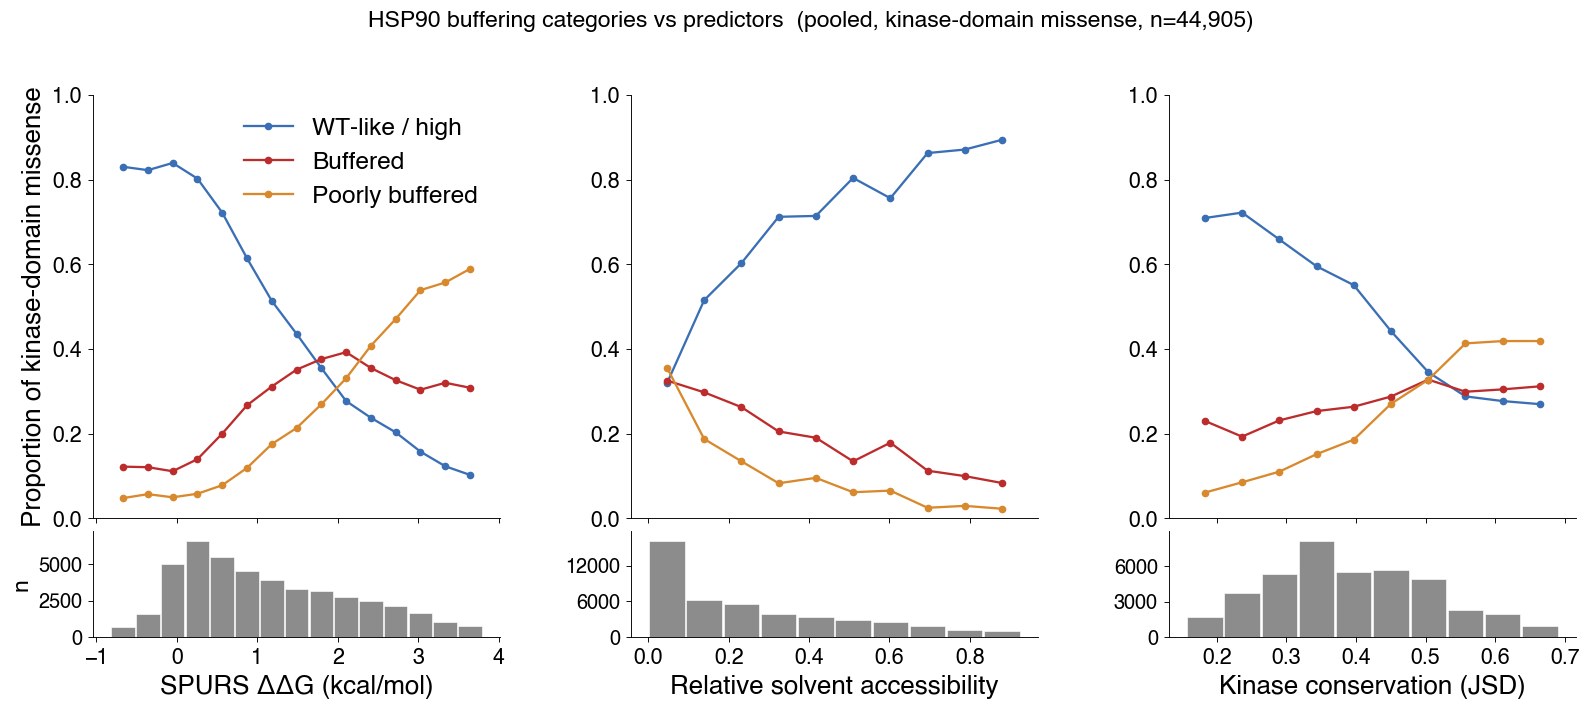

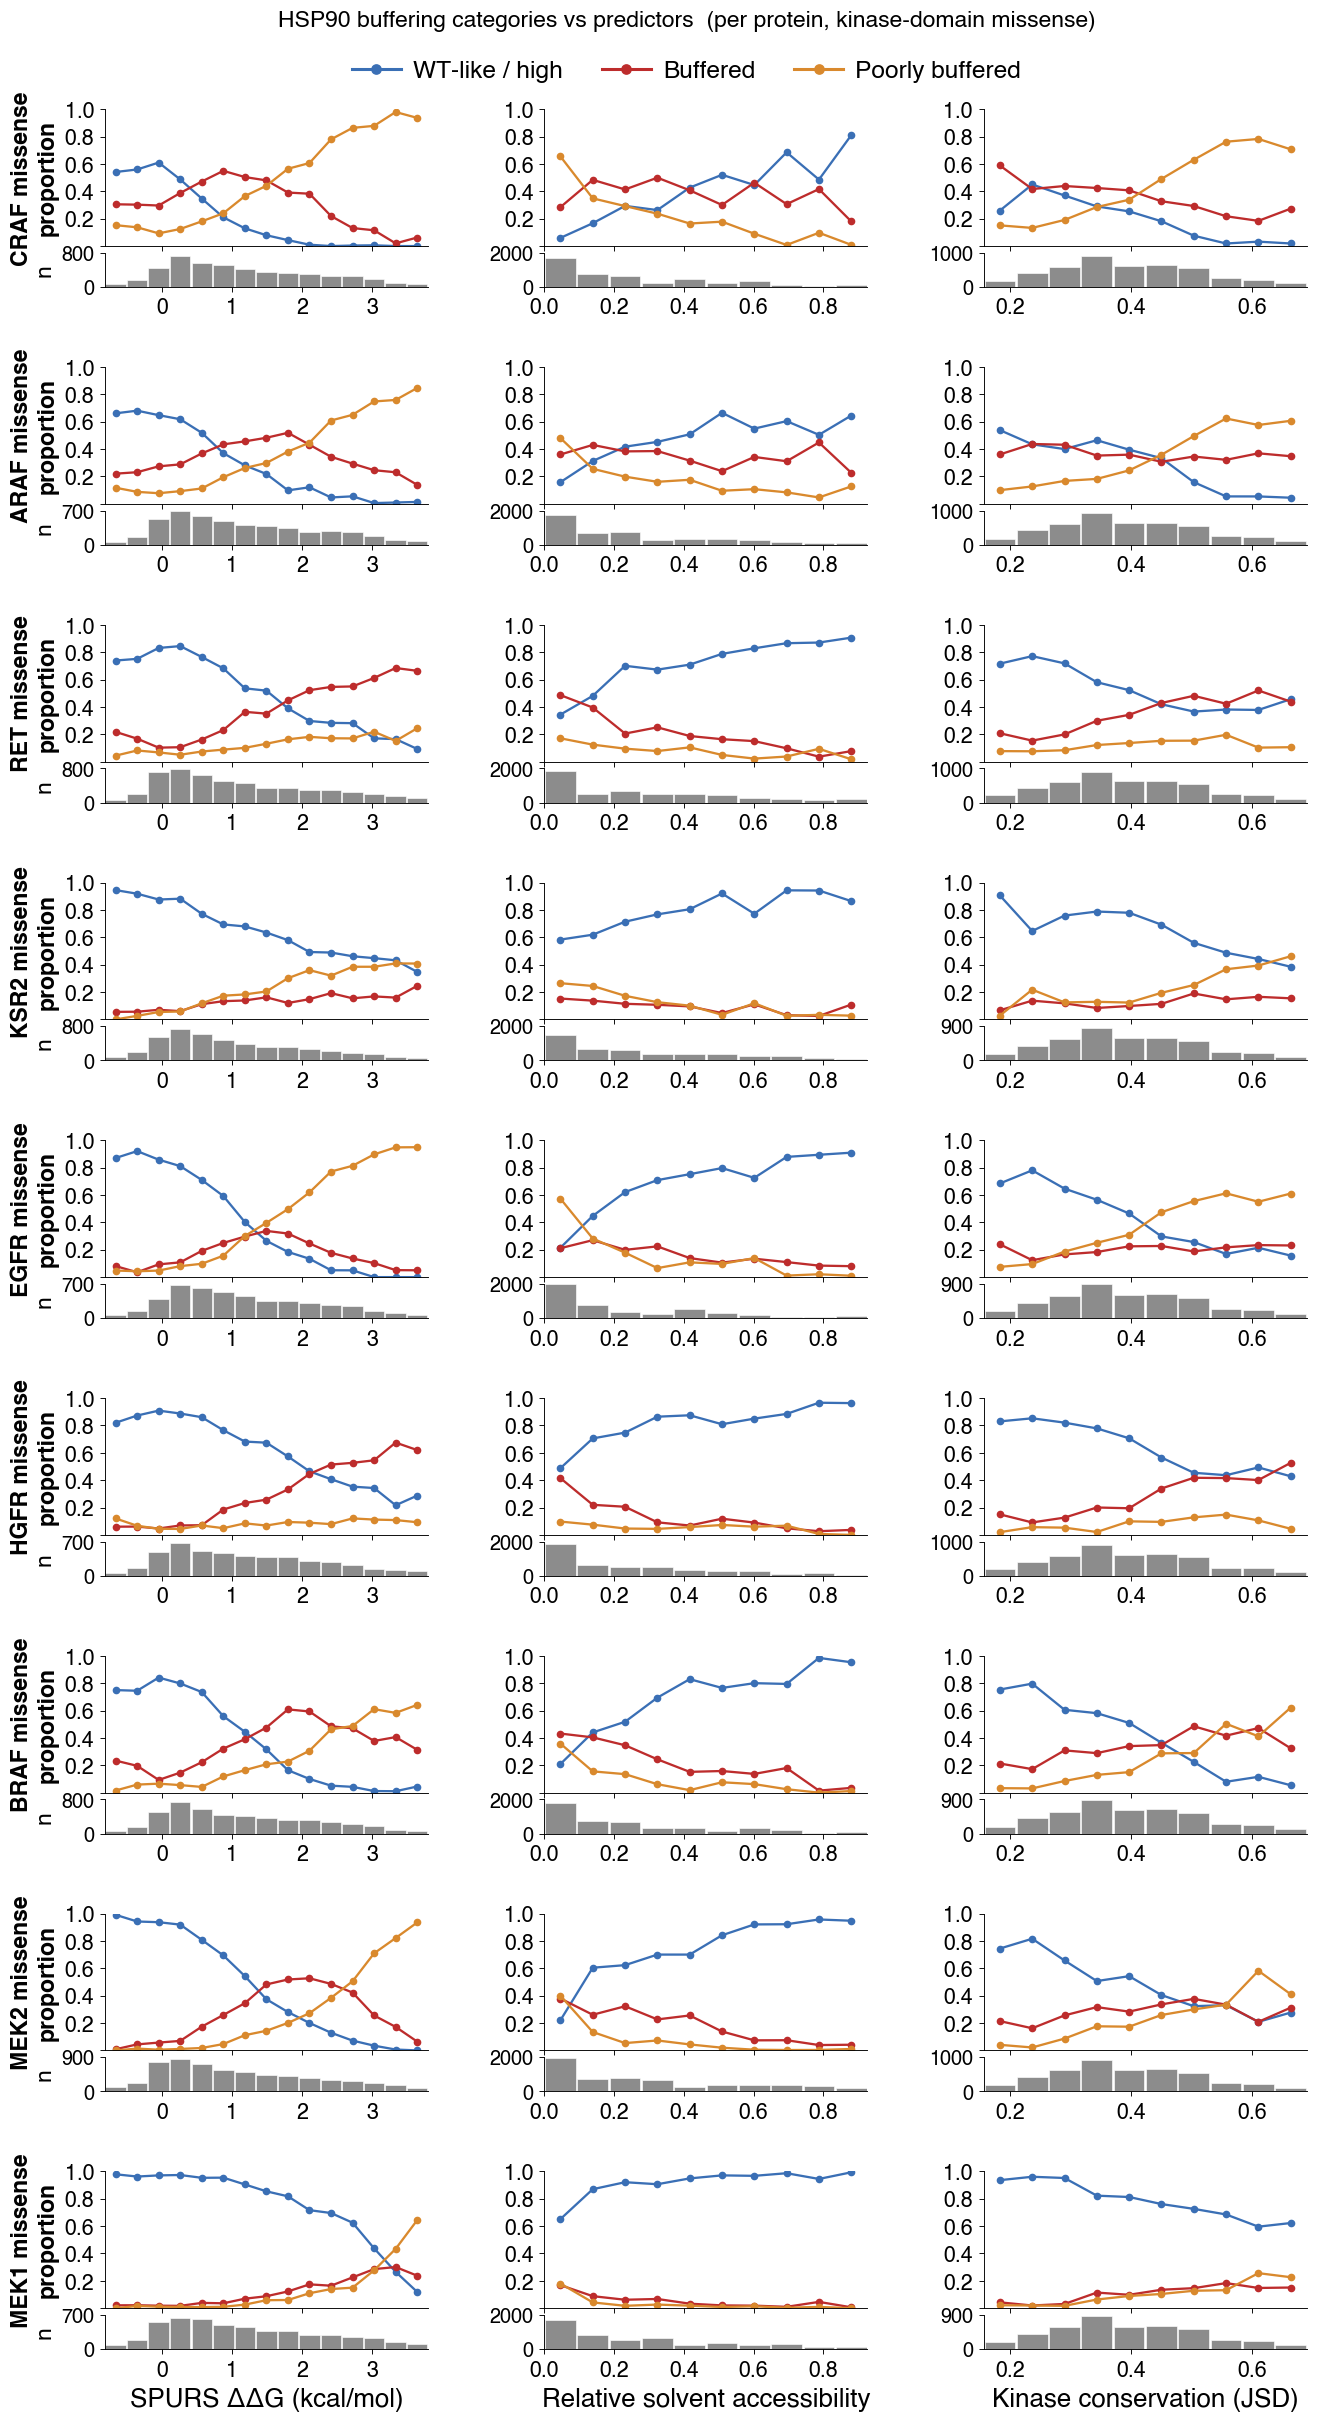

In [9]:
# Predictors, in the order the panels read. Grantham distance was dropped
# (2026-04-28): X->Cys substitutions at high Grantham are uniquely well
# tolerated, and that composition artefact made the predictor uninterpretable.
PREDICTORS = [
    {"col": "ddG_SPURS",        "label": "SPURS ΔΔG (kcal/mol)",         "n_bins": 15},
    {"col": "relative_sasa",    "label": "Relative solvent accessibility", "n_bins": 10},
    {"col": "jsd_conservation", "label": "Kinase conservation (JSD)",    "n_bins": 10},
]
# Lines in the same top-to-bottom order as the buffering bar panels.
CATEGORIES = [("wt_like",  "WT-like / high",  utils.BUFFERING_COLORS["WT-like or high"]),
              ("buffered", "Buffered",        utils.BUFFERING_COLORS["Buffered"]),
              ("poor",     "Poorly buffered", utils.BUFFERING_COLORS["Poorly buffered"])]
CLASS_KEY = {"WT-like or high": "wt_like", "Buffered": "buffered",
             "Poorly buffered": "poor"}
X_CLIP_PCT = (0.5, 99.5)

cohort = kd.dropna(subset=["buffering_class"]).copy()
cohort["cat"] = cohort.buffering_class.map(CLASS_KEY)
print("predictor coverage on the paired kinase-domain cohort:")
for pc in PREDICTORS:
    print(f"  {pc['col']:20s} {cohort[pc['col']].notna().mean():6.1%}")


def bin_edges(col, n_bins):
    """Uniform-width edges over the clipped range.

    Uniform rather than quantile on purpose: the shape of the relationship is
    the result, and quantile bins would flatten the ddG profile's inverted U.
    Edges come from the POOLED data so every per-protein panel in a column
    shares an x-axis and can be compared across rows.
    """
    s = cohort[col].dropna()
    lo, hi = np.nanpercentile(s, X_CLIP_PCT)
    return np.linspace(lo, hi, n_bins + 1)


def binned(sub, col, edges):
    """Per-bin count and fraction in each buffering class."""
    s = sub[[col, "cat"]].dropna()
    if s.empty:
        return pd.DataFrame()
    idx = np.digitize(s[col].to_numpy(), edges) - 1
    idx = np.clip(idx, 0, len(edges) - 2)
    s = s.assign(bin=idx)
    out = []
    for b, g in s.groupby("bin"):
        row = {"bin_center": (edges[b] + edges[b + 1]) / 2, "n": len(g)}
        for _k, key in CLASS_KEY.items():
            row[f"frac_{key}"] = float((g.cat == key).sum() / len(g))
        out.append(row)
    return pd.DataFrame(out).sort_values("bin_center")


EDGES = {pc["col"]: bin_edges(pc["col"], pc["n_bins"]) for pc in PREDICTORS}

# 4F — pooled over the nine profiled kinases.
prof_global = {(None, pc["col"]): binned(cohort, pc["col"], EDGES[pc["col"]])
               for pc in PREDICTORS}
fig, _ = utils.plot_univariate_profiles(
    prof_global, EDGES, predictors=PREDICTORS, categories=CATEGORIES,
    suptitle="HSP90 buffering categories vs predictors  "
             f"(pooled, kinase-domain missense, n={len(cohort):,})")
utils.save_figure(fig, FIG / "fig4f_univariate_pooled")
plt.show()

# S4C — the same, resolved by protein, on the shared per-column axes.
# utils.HSP90_ORDER is the figure-4 ordering (WT-dependence tiers, matching
# 4D/S4A). Deliberately not utils.DN_ORDER, which is figure 3's and contains no
# MEK at all — ordering through it dropped MEK1 and MEK2 without a word.
PROTS = [p for p in utils.HSP90_ORDER if p in set(cohort.protein)]
missing = sorted(set(cohort.protein) - set(PROTS))
assert not missing, f"proteins in the cohort but not in the tier order: {missing}"
prof_pp = {(p, pc["col"]): binned(cohort[cohort.protein == p], pc["col"],
                                  EDGES[pc["col"]])
           for p in PROTS for pc in PREDICTORS}
fig, _ = utils.plot_univariate_profiles(
    prof_pp, EDGES, predictors=PREDICTORS, categories=CATEGORIES,
    proteins=PROTS,
    suptitle="HSP90 buffering categories vs predictors  "
             "(per protein, kinase-domain missense)")
utils.save_figure(fig, FIG / "figs4c_univariate_per_protein")
plt.show()


## 4G — buffering by activity class

Buffering composition within each activity class, so the two axes of the
dataset are crossed. Dominant negatives take precedence over "low activity"
because DN is a strict subset of it by construction.

kinase-domain missense+deletion with both a buffering and an activity class: 46,249


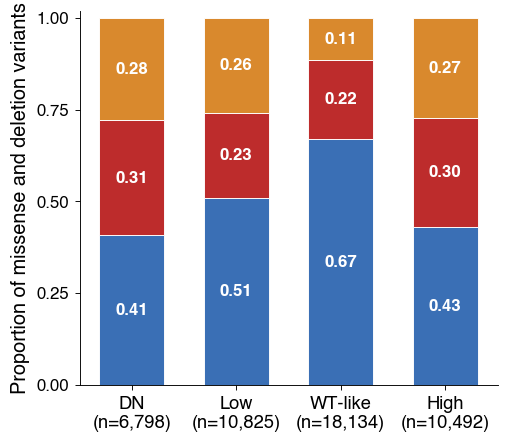

buffering_class,WT-like or high,Buffered,Poorly buffered
activity_class,,,
DN,40.7,31.3,27.9
Low,50.9,23.3,25.9
WT-like,67.1,21.5,11.4
High,43.0,29.8,27.2


In [10]:
act_base = pd.read_csv(
    ANNOTATED_COMBINED, sep="\t", low_memory=False,
    usecols=["protein", "library", "variant", "assay", "assay_treatment",
             "Mutation Type", "classification_2.5pct", "DN_EV"])
act_base = act_base[(act_base.assay == "activity")
                    & act_base.assay_treatment.isin(utils.BASELINE_TREATMENTS)
                    & act_base["Mutation Type"].isin(["missense", "deletion"])]
act_base["activity_group"] = activity_group(act_base)

xg = kd_md.merge(act_base[["protein", "library", "variant", "activity_group"]],
              on=["protein", "library", "variant"], how="inner")
xg = xg.dropna(subset=["buffering_class", "activity_group"])
print(f"kinase-domain missense+deletion with both a buffering and an activity class: "
      f"{len(xg):,}")

# DN first, then increasing pathway output: DN is the headline class, so it
# leads rather than following the usual high-to-low convention.
# `classification_2.5pct` is lower-case in the score table, so map to display
# names before ordering — reindexing on the capitalised names silently matched
# only "DN" and collapsed the panel to a single bar.
ACTIVITY_CLASS_ORDER = ["DN", "Low", "WT-like", "High"]
ACTIVITY_DISPLAY = {"DN": "DN", "low": "Low", "wt-like": "WT-like",
                    "high": "High"}
xg["activity_class"] = xg.activity_group.map(ACTIVITY_DISPLAY)
unmapped = sorted(set(xg.activity_group.dropna()) - set(ACTIVITY_DISPLAY))
assert not unmapped, f"unmapped activity classes: {unmapped}"
comp = (xg.groupby(["activity_class", "buffering_class"]).size()
        .unstack(fill_value=0)
        .reindex(index=[g for g in ACTIVITY_CLASS_ORDER
                        if g in set(xg.activity_class)],
                 columns=utils.BUFFERING_STACK_ORDER, fill_value=0))
n_comp = comp.sum(axis=1)
# Vertical bars on the same fixed physical pitch as 4C, so a bar in this panel
# is exactly as wide as a bar there and the two can be read side by side. No
# legend: the colour key comes from 4C.
fig, _ = utils.plot_stacked_vbar(
    comp.div(n_comp, axis=0), colors=utils.BUFFERING_COLORS,
    n_by_row=n_comp.astype(int), show_legend=False,
    yticks=[0, 0.25, 0.5, 0.75, 1.0],
    ylabel="Proportion of missense and deletion variants")
utils.save_figure(fig, FIG / "fig4g_buffering_by_activity_class")
plt.show()
display((comp.div(n_comp, axis=0) * 100).round(1))

## S4B — per-protein effect, ordered by importance

Two quantities in one panel, and they are not the same thing:

- **Cell colour = the standardized log-odds coefficient** for Buffered vs
  WT-like/high, from a *univariate* multinomial logit `buffering class ~
  feature` fitted within one protein. Signed: it says which way the feature
  pushes. Univariate one feature at a time avoids the quasi-separation that
  makes a full per-protein multivariate fit unstable.
- **Row order and the bars beside them = mean per-protein McFadden
  pseudo-R²** of those same fits. Unsigned magnitude. This is what stops a
  large coefficient on a feature that explains nothing from reading as a
  result.

So the colour is *direction* and the bar is *importance*; do not read the
colour as pseudo-R². `pseudo_r2` is a property of the (protein, feature) fit
and repeats across both contrast rows in the table, hence the dedupe below
before averaging.

The fits are expensive and precomputed:
`scripts/plot_hsp90_factor_per_protein_importance.py` writes the table, using
the cohort and pooled z-scores from `regress_hsp90_buffering_factors.py`
(pooled, not per protein, so coefficients are comparable across proteins).
A cell is left blank unless all three buffering classes are present with
≥ 5 distinct POSITIONS each — positions, not variants, because most
structural features are position-level. This cell only loads and draws.

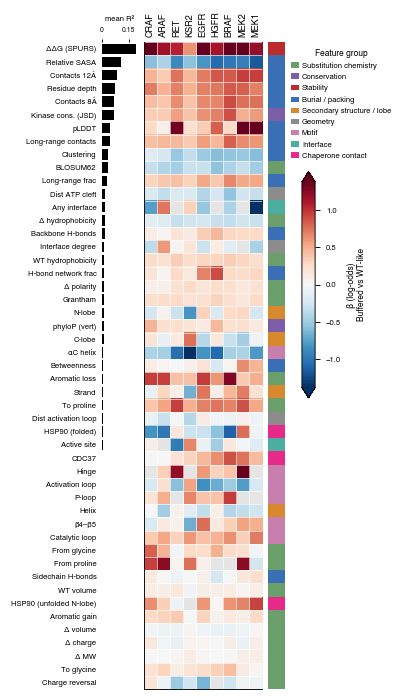

49 features x 9 proteins; colour = univariate beta for Buffered vs WT-like


In [11]:
# S4B reads the precomputed per-protein univariate fits rather than refitting:
# the fits are the output of regress_hsp90_buffering_factors.py, and refitting
# here would risk the figure and the statistics drifting apart.
FA = OUTPUT / "hsp90" / "factor_analysis"
pp = pd.read_csv(FA / "buffering_factor_per_protein_importance.tsv", sep="\t")
betas = pp[pp.contrast == "buffered"]          # Buffered vs WT-like

# Feature order is by MEAN per-protein univariate pseudo-R², highest at top, so
# the rows are sorted by how much each feature actually explains. The contrast
# column duplicates each (protein, feature) pair, hence the dedupe.
mean_r2 = (pp.drop_duplicates(["protein", "feature"])
           .groupby("feature").pseudo_r2.mean().to_dict())

# Feature grouping and display names, from the factor-analysis feature spec
# (docs/hsp90_factor_features.md). Written out here so the figure does not
# depend on importing a plotting script.
FEATURE_GROUPS = [
    ("Substitution chemistry", [
        ("delta_hydrophobicity_z", "Δ hydrophobicity"), ("delta_volume_z", "Δ volume"),
        ("delta_charge_z", "Δ charge"), ("delta_polarity_z", "Δ polarity"),
        ("delta_mw_z", "Δ MW"), ("grantham_distance_z", "Grantham"),
        ("blosum62_score_z", "BLOSUM62"),
        ("wt_hydrophobicity_z", "WT hydrophobicity"), ("wt_volume_z", "WT volume"),
        ("to_proline", "To proline"), ("from_proline", "From proline"),
        ("to_glycine", "To glycine"), ("from_glycine", "From glycine"),
        ("charge_reversal", "Charge reversal"), ("aromatic_loss", "Aromatic loss"),
        ("aromatic_gain", "Aromatic gain")]),
    ("Conservation", [("jsd_conservation_z", "Kinase cons. (JSD)"),
                      ("phylop_vert_z", "phyloP (vert)")]),
    ("Stability", [("ddG_SPURS_z", "ΔΔG (SPURS)")]),
    ("Burial / packing", [
        ("relative_sasa_z", "Relative SASA"), ("plddt_z", "pLDDT"),
        ("contact_number_8A_z", "Contacts 8Å"), ("contact_number_12A_z", "Contacts 12Å"),
        ("depth_z", "Residue depth"), ("n_backbone_hbonds_z", "Backbone H-bonds"),
        ("n_sidechain_hbonds_z", "Sidechain H-bonds"),
        ("hbond_network_fraction_z", "H-bond network frac"),
        ("long_range_contacts_z", "Long-range contacts"),
        ("long_range_contact_fraction_z", "Long-range frac"),
        ("betweenness_centrality_z", "Betweenness"),
        ("clustering_coefficient_z", "Clustering")]),
    ("Secondary structure / lobe", [
        ("ss_helix", "Helix"), ("ss_strand", "Strand"),
        ("is_n_lobe", "N-lobe"), ("is_c_lobe", "C-lobe")]),
    ("Geometry", [("dist_to_atp_site_z", "Dist ATP cleft"),
                  ("dist_to_activation_loop_z", "Dist activation loop"),
                  ("n_partners_z", "Interface degree")]),
    ("Motif", [
        ("motif_gly_rich_loop", "P-loop"), ("motif_alphaC_helix", "αC helix"),
        ("motif_beta4_beta5", "β4–β5"), ("motif_hinge", "Hinge"),
        ("motif_DFG", "DFG"), ("motif_activation_loop", "Activation loop"),
        ("motif_catalytic_loop", "Catalytic loop")]),
    ("Interface", [
        ("active_site", "Active site"), ("interface_pdb_curated", "Protein interface"),
        ("at_any_chaperone_interface", "Chaperone interface"),
        ("at_any_interface", "Any interface")]),
    ("Chaperone contact", [
        ("at_hsp90_unfolded", "HSP90 (unfolded N-lobe)"),
        ("at_hsp90_folded", "HSP90 (folded)"), ("at_cdc37", "CDC37")]),
]
FEATURE_LABELS = {f: lab for _g, fs in FEATURE_GROUPS for f, lab in fs}
GROUP_COLORS = {"Substitution chemistry": "#6a9e6a", "Conservation": "#7b5ea7",
                "Stability": "#bd2c2c", "Burial / packing": "#3a6fb5",
                "Secondary structure / lobe": "#d9892d", "Geometry": "#8c8c8c",
                "Motif": "#c97fae", "Interface": "#4cae9e",
                "Chaperone contact": "#e7298a"}
unlabelled = sorted(set(betas.feature) - set(FEATURE_LABELS))
assert not unlabelled, f"features fitted but not in the spec: {unlabelled}"

# Same figure-4 ordering as 4D/S4A/S4C.
PROTS_S4B = [p for p in utils.HSP90_ORDER if p in set(betas.protein)]
dropped = sorted(set(betas.protein) - set(PROTS_S4B))
assert not dropped, f"proteins fitted but not plotted: {dropped}"
fig, _ = utils.plot_beta_heatmap(
    betas, mean_r2, col_order=PROTS_S4B, feature_labels=FEATURE_LABELS,
    feature_groups=FEATURE_GROUPS, group_colors=GROUP_COLORS)
utils.save_figure(fig, FIG / "figs4b_per_protein_univariate_r2")
plt.show()
print(f"{len(set(betas.feature))} features x {len(PROTS_S4B)} proteins; "
      f"colour = univariate beta for Buffered vs WT-like")


---
## Outputs

Written to `output/figures/fig4/`, with the supporting tables beside each panel.

Notes on this figure:
- **4E** structural renders come from
  `scripts/paint_consensus_buffering_structures.py`; this notebook writes the
  per-position table it consumes.
- **S4B** loads precomputed fits; re-run
  `scripts/regress_hsp90_buffering_factors.py` if the cohort changes. It
  currently reads `at_any_interface` from the raw curated interface set, so it
  will not see the MEK1→MEK2 augmentation until
  `config/paths.yaml: interactions` is repointed to the augmented file.